Data generated by Todd is missing alpha's and delta's for intermediate potentials - probably to keep data clean and accurate and not get bogged down by experimental error <br>
I am going to calculate my own kinetic parameters and cross verify with Todd's data by plotting <br>
Experimental parameters: <br>
KOH/HClO4 concs: 0.1, 0.25, 0.5, 1 (M) <br>
CO Pressure: 0.1, 1, 10, 100 <br>
16 different condiitons for each acidic/basic CO oxidation: 4 different setups <br>
Assume that pH reaction order data will be less accurate than CO reaction order or transfer coefficient data - different setups for different pHs <br>
Potential ranges: 0.5 - 1 (vs RHE) <br>
Catalysts: Pt100, Pt66Ru33, Pt50Ru50 <br>
<br>
Units: <br>
Potential: V vs RHE <br>
Current: mA/cm2 <br>
<br>
Data was interpolated to put all data sets on the same grid. <br>
Save final data and import in different workspace. <br>

In [1]:
import pandas as pd
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

import sys
import os 
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import _utils

In [2]:
# Experimental conditions (Pt100 KOH) and constants

C_KOH_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
conditions = list(itertools.product(C_KOH_list, P_CO_list))

R, T, F = 8.3145, 298.15, 96485

In [3]:
# Load current density data + classification

current_densities = pd.read_excel('Summary_current_densities.xlsx', sheet_name='Pt100 KOH Current Densities')
experiments = {}
for i, (C_KOH, P_CO) in enumerate(conditions):
    col_idx = i * 2
    subset = current_densities.iloc[3:, col_idx : col_idx+2].copy()
    subset.columns = ['E', 'j']
    # Force numeric, coerce bad values to NaN, then drop
    subset['E'] = pd.to_numeric(subset['E'], errors='coerce')
    subset['j'] = pd.to_numeric(subset['j'], errors='coerce')
    subset = subset.dropna()
    experiments[(C_KOH, P_CO)] = subset

In [4]:
# Convert potential to SHE scale and interpolate to common E points
for C_KOH in C_KOH_list:
    E_ref = 0 - 0.0592*(14 + np.log10(C_KOH))
    for P_CO in P_CO_list:
        condition = (C_KOH, P_CO)
        experiments[condition]['E_SHE'] = experiments[condition]['E'] + E_ref

min_E = max(experiments[c]['E_SHE'].min() for c in experiments)
max_E = min(experiments[c]['E_SHE'].max() for c in experiments)
E_interp_SHE = np.linspace(min_E, max_E, 200)

# Store interpolated data separately
experiments_interp = {}
for P_CO in P_CO_list:
    for C_KOH in C_KOH_list:
        condition = (C_KOH, P_CO)
        E = experiments[condition]['E_SHE']
        j = experiments[condition]['j']
        
        f_interp = PchipInterpolator(E, j)
        j_interp = f_interp(E_interp_SHE)

        experiments_interp[condition] = {}
        experiments_interp[condition]['j'] = j_interp
        experiments_interp[condition]['E'] = E_interp_SHE # E is vs SHE

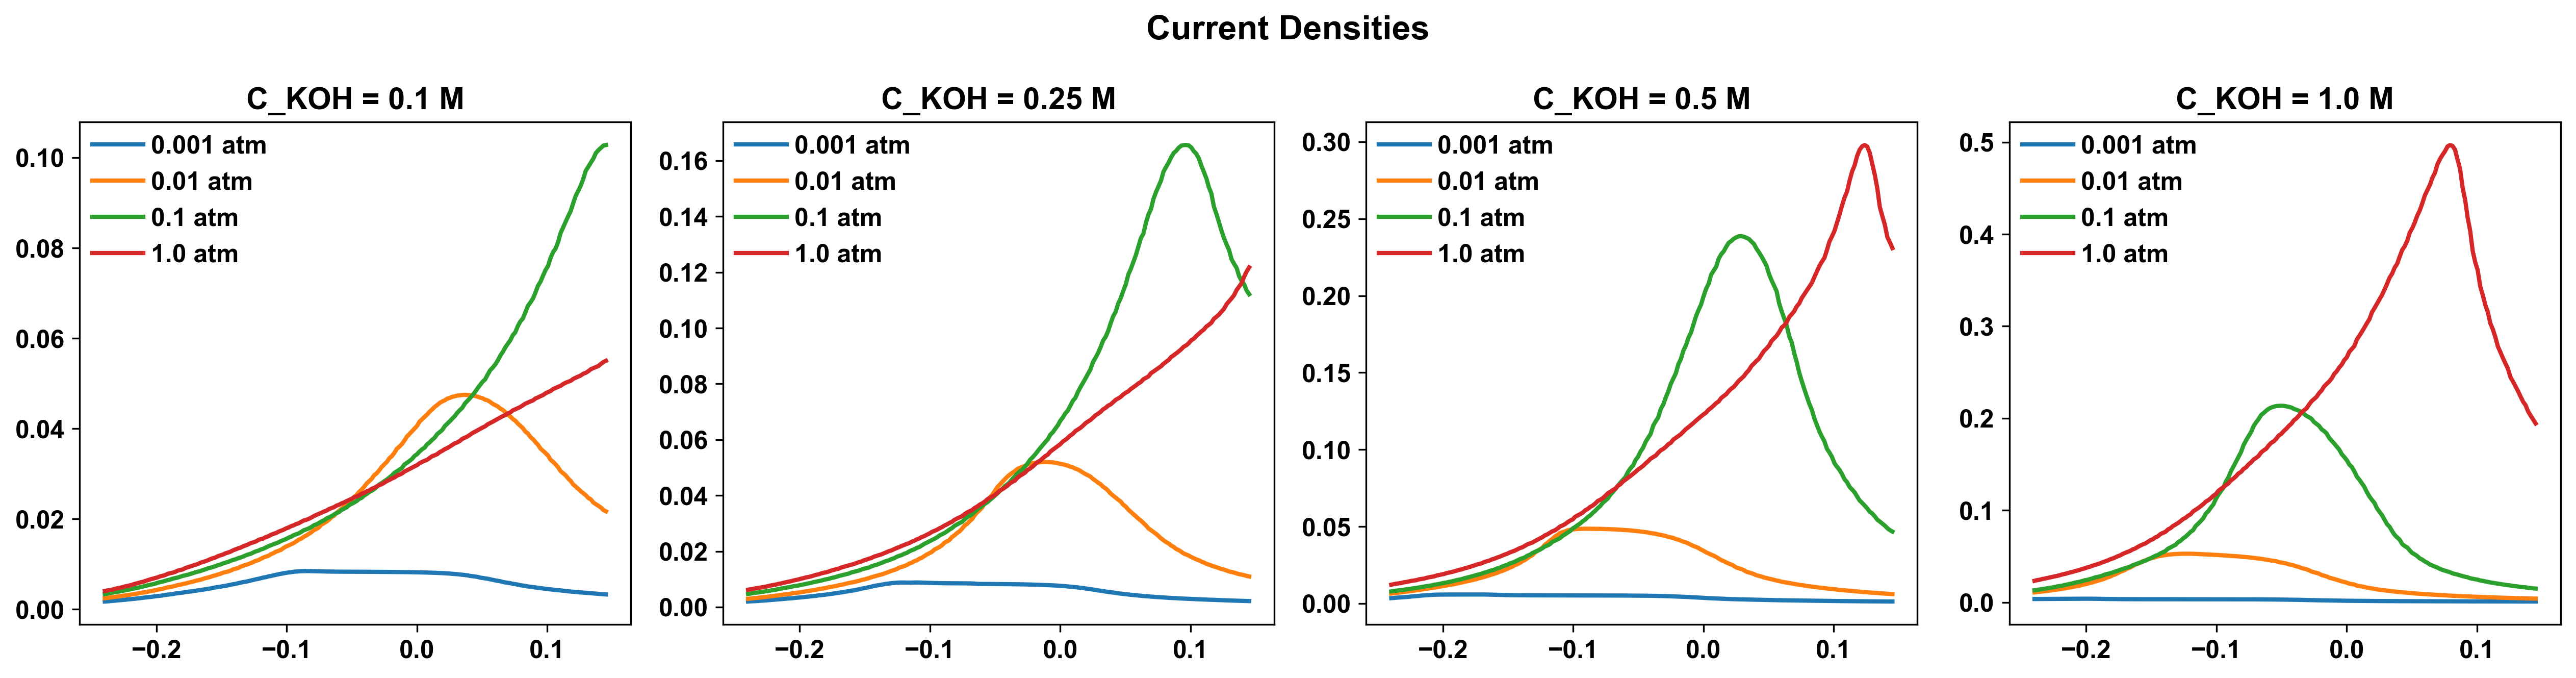

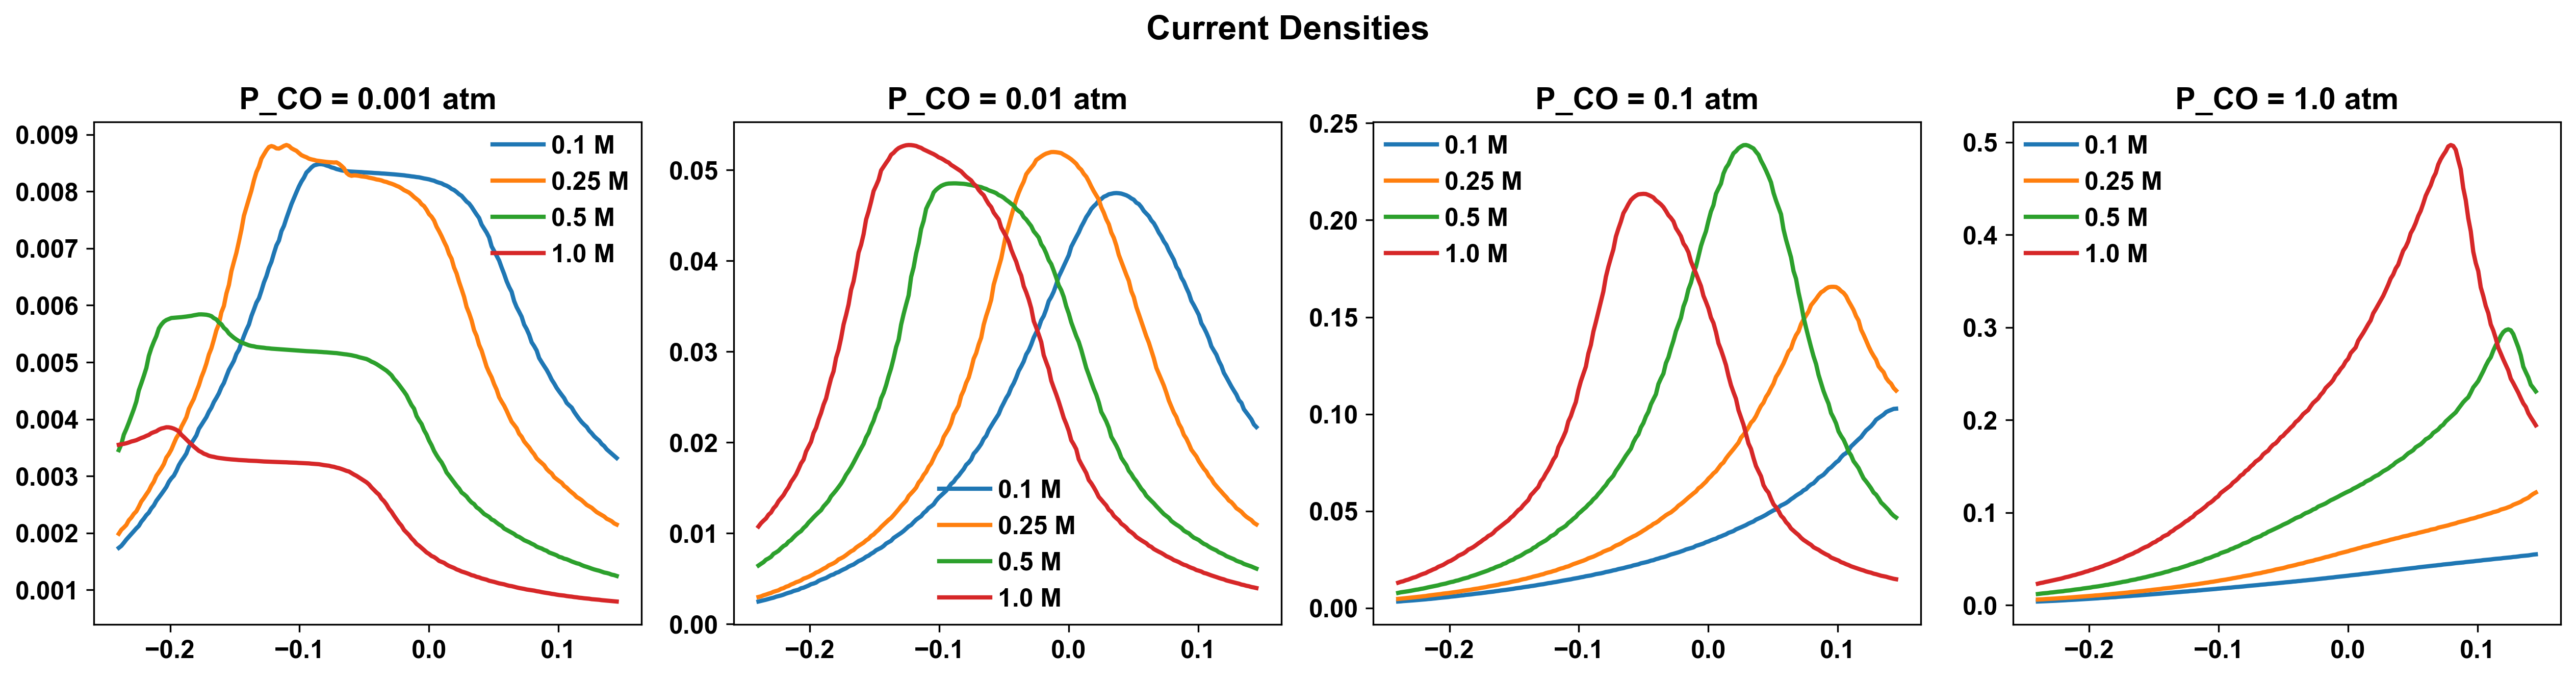

In [5]:
# Plotting current densities 

fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('Current Densities', fontsize=16, fontweight='bold')
for i, target_KOH in enumerate(C_KOH_list):
    plt.subplot(1, 4, i + 1) 
    plt.title(f'C_KOH = {target_KOH} M')
    for (C_KOH, P_CO) in conditions:
        if C_KOH == target_KOH:
            E = experiments_interp[(C_KOH, P_CO)]['E']
            j = experiments_interp[(C_KOH, P_CO)]['j']
            plt.plot(E, j, label=f'{P_CO} atm')
    plt.legend()
plt.tight_layout()

fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('Current Densities', fontsize=16, fontweight='bold')
for i, target_CO in enumerate(P_CO_list):
    plt.subplot(1, 4, i + 1) 
    plt.title(f'P_CO = {target_CO} atm')
    for (C_KOH, P_CO) in conditions:
        if P_CO == target_CO:
            E = experiments_interp[(C_KOH, P_CO)]['E']
            j = experiments_interp[(C_KOH, P_CO)]['j']
            plt.plot(E, j, label=f'{C_KOH} M')  
    plt.legend()
plt.tight_layout()

In [6]:
# Load Todd's alpha data + classification

alpha_todd_raw = pd.read_excel('Summary_TCs.xlsx', sheet_name='Pt100 KOH')
alpha_todd = {}
for i, (C_KOH, P_CO) in enumerate(conditions):
    col_idx = i * 2
    subset = alpha_todd_raw.iloc[3:, col_idx : col_idx+2].copy()
    subset.columns = ['E', 'alpha'] # in RHE
    subset = subset.dropna()
    alpha_todd[(C_KOH, P_CO)] = subset
    
    E_ref = 0 - 0.0592*(14 + np.log10(C_KOH))
    alpha_todd[(C_KOH, P_CO)]['E'] = alpha_todd[(C_KOH, P_CO)]['E'] + E_ref

In [7]:
# Calculate alpha from current data

for condition in conditions:
    E = experiments_interp[condition]['E']
    j = experiments_interp[condition]['j']
    lnj = np.log(j)

    alpha = (R*T/F)*np.gradient(lnj, E)    
    experiments_interp[condition]['alpha'] = alpha

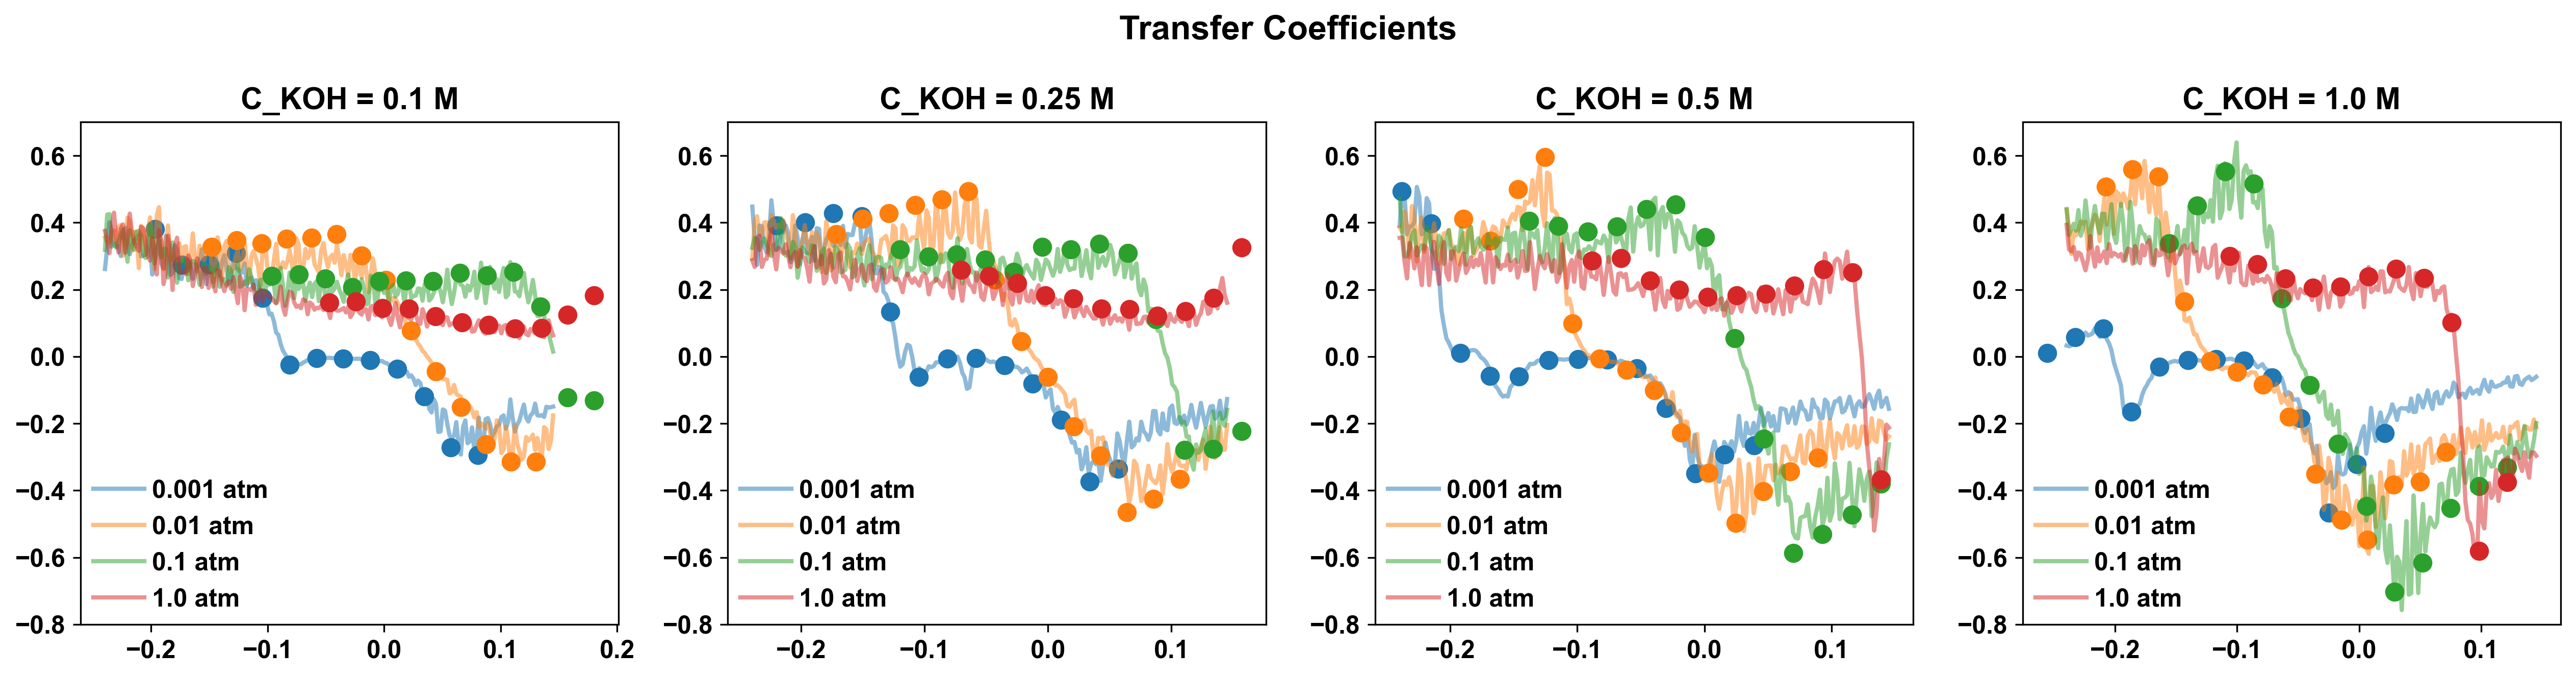

In [8]:
# Plotting alphas

fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('Transfer Coefficients', fontsize=16, fontweight='bold')
for i, target_KOH in enumerate(C_KOH_list):
    plt.subplot(1, 4, i + 1) 
    plt.title(f'C_KOH = {target_KOH} M')
    for (C_KOH, P_CO) in conditions:
        if C_KOH == target_KOH:
            E = experiments_interp[(C_KOH, P_CO)]['E']
            alpha = experiments_interp[(C_KOH, P_CO)]['alpha']
            line, = plt.plot(E, alpha, label=f'{P_CO} atm', alpha=0.5)
            
            E_todd = alpha_todd[(C_KOH, P_CO)]['E']
            alpha_todd_val = alpha_todd[(C_KOH, P_CO)]['alpha']
            plt.plot(E_todd, alpha_todd_val, 'o', markersize=8, color=line.get_color())

    plt.ylim(-0.8, 0.7)
    plt.legend()
plt.tight_layout()

In [9]:
# Load Todd's delta_OH data + classification

delta_OH_todd_raw = pd.read_excel('Summary_pH_order.xlsx', sheet_name='Pt100 KOH')
delta_OH_todd = {}
for i, P_CO in enumerate(P_CO_list):
    col_idx = i * 2
    subset = delta_OH_todd_raw.iloc[3:, col_idx : col_idx+2].copy()
    subset.columns = ['E', 'delta_OH'] # in SHE
    subset = subset.dropna()
    delta_OH_todd[(P_CO)] = subset

In [10]:
# Calculate delta_OH from current data

for P_CO in P_CO_list:
    j_interp_matrix = []
    for C_KOH in C_KOH_list:
        condition = (C_KOH, P_CO)
        j_interp_matrix.append(experiments_interp[condition]['j'])
    
    delta_OH = np.polyfit(np.log(C_KOH_list).transpose(), np.log(j_interp_matrix), deg=1)[0]
    for C_KOH in C_KOH_list: experiments_interp[(C_KOH, P_CO)]['delta_OH'] = delta_OH    

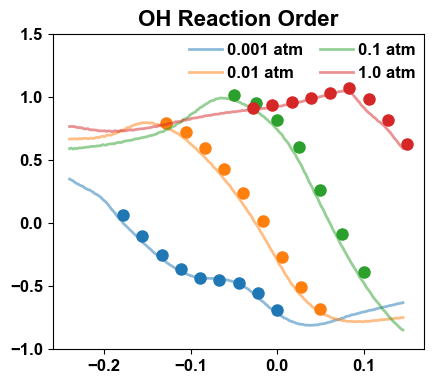

In [11]:
# Plotting delta_OH

fig = plt.figure(figsize=(4.5, 4), dpi=100)
plt.title('OH Reaction Order', fontsize=16, fontweight='bold')
for i, P_CO in enumerate(P_CO_list):
    delta_OH = experiments_interp[(C_KOH_list[1], P_CO)]['delta_OH'] # Arbitrary C_KOH
    E_SHE = experiments_interp[(C_KOH_list[1], P_CO)]['E'] # Arbitrary C_KOH
    line, = plt.plot(E_SHE, delta_OH, label=f'{P_CO} atm', alpha=0.5) 
    E_todd = delta_OH_todd[(P_CO)]['E']
    delta_OH_todd_val = delta_OH_todd[(P_CO)]['delta_OH']
    plt.plot(E_todd, delta_OH_todd_val, 'o', markersize=8, color=line.get_color())
plt.legend(ncols=2)
plt.ylim(-1, 1.5)
plt.tight_layout()

In [12]:
# Load Todd's delta_CO data + classification

delta_CO_todd_raw = pd.read_excel('Summary_CO_order.xlsx', sheet_name='Pt100 KOH')
delta_CO_todd = {}
conditions_delta_CO = list(itertools.product(C_KOH_list, P_CO_list[0:-1]))
for i, (C_KOH, P_CO) in enumerate(conditions_delta_CO):
    col_idx = i * 2
    subset = delta_CO_todd_raw.iloc[3:, col_idx : col_idx+2].copy()
    subset.columns = ['E', 'delta_CO'] # in RHE
    subset = subset.dropna()
    delta_CO_todd[(C_KOH, P_CO)] = subset

    E_ref = 0 - 0.0592*(14 + np.log10(C_KOH))
    delta_CO_todd[(C_KOH, P_CO)]['E'] = delta_CO_todd[(C_KOH, P_CO)]['E'] + E_ref

In [13]:
# Calculate delta_CO from current data

for (C_KOH, P_CO) in conditions_delta_CO:
    condition = (C_KOH, P_CO)
    idx = int(np.where(P_CO_list == P_CO)[0][0])
    E = experiments_interp[condition]['E']
    j_1 = experiments_interp[(C_KOH, P_CO)]['j']
    j_2 = experiments_interp[(C_KOH, P_CO_list[idx + 1])]['j']

    delta_CO = (np.log(j_2) - np.log(j_1)) / (np.log(P_CO_list[idx + 1]) - np.log(P_CO))
    experiments_interp[condition]['delta_CO'] = delta_CO

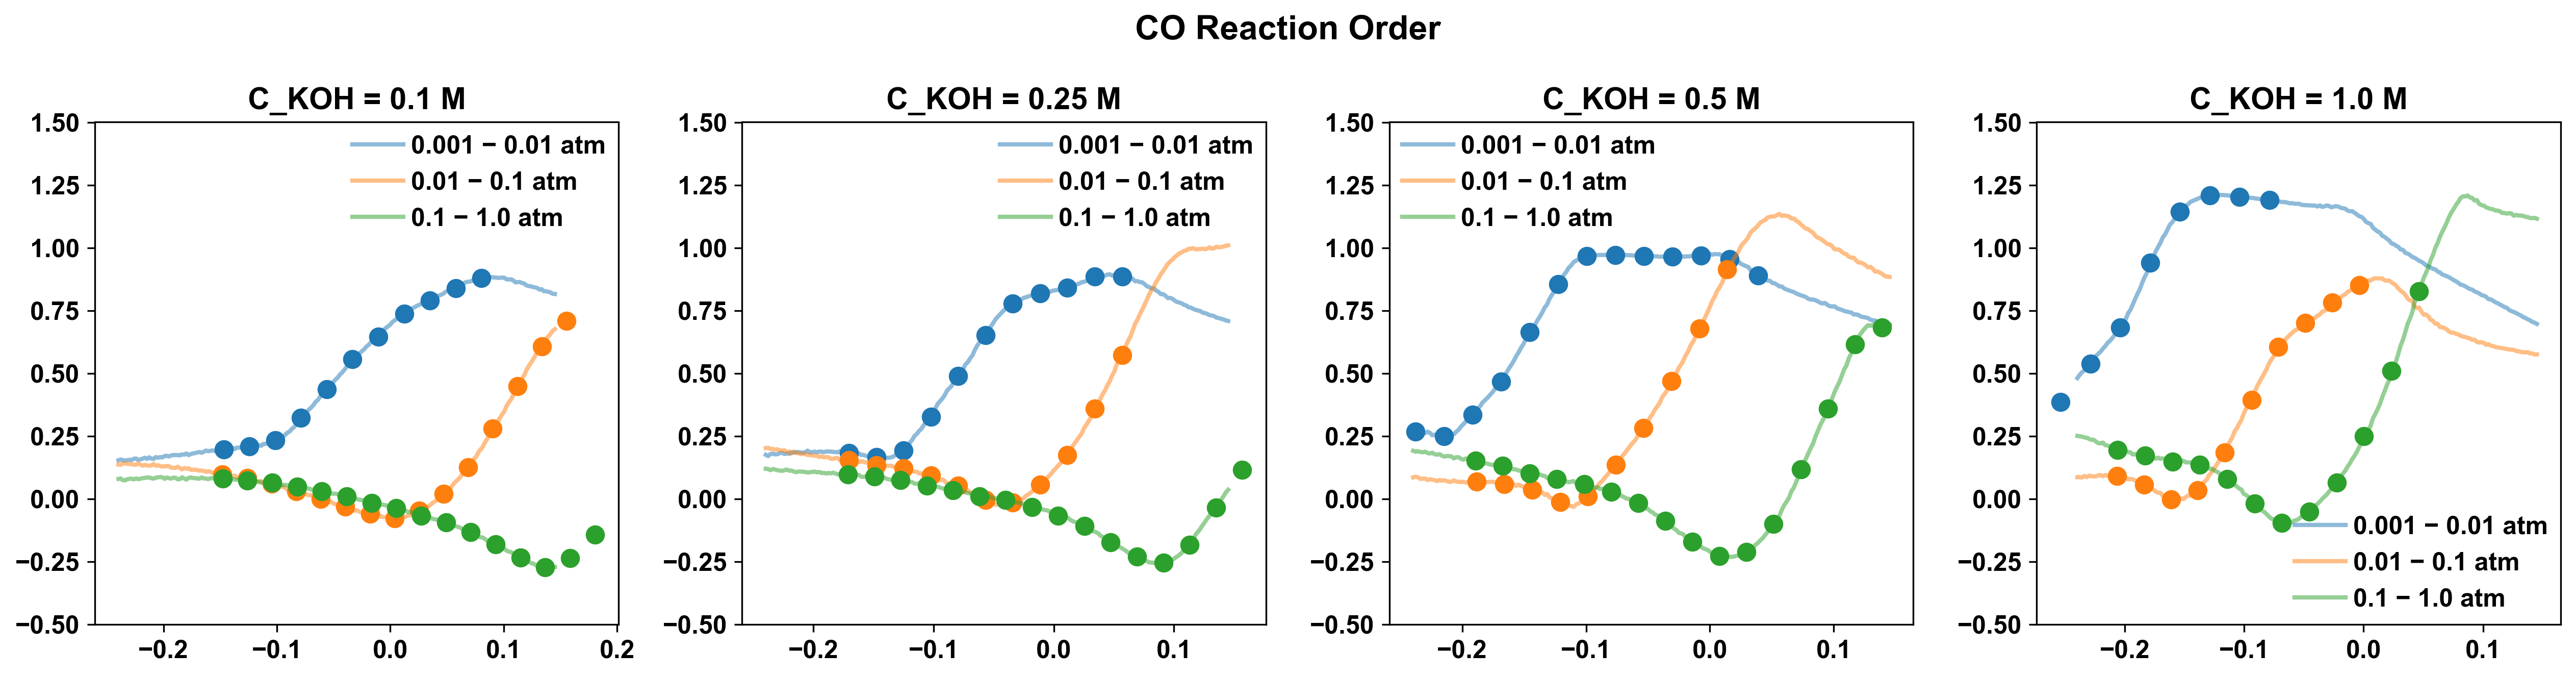

In [14]:
# Plotting delta_CO

fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('CO Reaction Order', fontsize=16, fontweight='bold')
for i, target_KOH in enumerate(C_KOH_list):
    plt.subplot(1, 4, i + 1) 
    plt.title(f'C_KOH = {target_KOH} M')
    for (C_KOH, P_CO) in conditions_delta_CO:
        if C_KOH == target_KOH:
            E = experiments_interp[(C_KOH, P_CO)]['E']
            delta_CO = experiments_interp[(C_KOH, P_CO)]['delta_CO']
            idx = int(np.where(P_CO_list == P_CO)[0][0])
            P_CO_2 = P_CO_list[idx + 1]
            line, = plt.plot(E, delta_CO, label=f'{P_CO} - {P_CO_2} atm', alpha=0.5)
            
            E_todd = delta_CO_todd[(C_KOH, P_CO)]['E']
            delta_CO_todd_val = delta_CO_todd[(C_KOH, P_CO)]['delta_CO']
            plt.plot(E_todd, delta_CO_todd_val, 'o', markersize=8, color=line.get_color())

    plt.legend()
    plt.ylim(-0.5, 1.5)
plt.tight_layout()

In [15]:
import pickle

with open('Pt100_KOH.pkl', 'wb') as f:
    pickle.dump(experiments_interp, f)

In [16]:
experiments_interp

{(np.float64(0.1),
  np.float64(0.001)): {'j': array([0.00173917, 0.00177371, 0.00182702, 0.00188408, 0.00193272,
         0.00198088, 0.00203108, 0.00208131, 0.00212491, 0.00219886,
         0.00225144, 0.00231325, 0.00235742, 0.00243207, 0.00248402,
         0.00256466, 0.00262319, 0.00268287, 0.00274492, 0.00280901,
         0.00289818, 0.00295997, 0.00300704, 0.00309031, 0.00319068,
         0.00326437, 0.00332671, 0.00339651, 0.00351208, 0.00357762,
         0.00364314, 0.00371429, 0.00382992, 0.00389713, 0.0039672 ,
         0.00403529, 0.00412952, 0.00420144, 0.00430047, 0.00437347,
         0.00445341, 0.00455877, 0.004635  , 0.00475173, 0.00486387,
         0.00494299, 0.00502457, 0.00514552, 0.00521792, 0.00534182,
         0.00545984, 0.00556863, 0.00566171, 0.00581036, 0.00592545,
         0.00604648, 0.00612293, 0.0062558 , 0.00640114, 0.00651168,
         0.00665772, 0.00676331, 0.00691371, 0.00705219, 0.00713696,
         0.0073021 , 0.00739435, 0.00752858, 0.00765266, 0